# Pairwise mutation effects

### Pointwise mutations

We wish to investigate the effects of pointwise and pairwise mutations at different locations along the promoter.
To this end, we will consider how mutations at one or more points shift mean expression.
Let $S$ be the set of observed promoter sequences, and let $\chi:S\to \mathbb{R}$ be the map associating to each sequence its observed expression level.

For a sequence of interest $s\in S$, we denote its wildtype by $s^{*}$.
For any pair of equal length $n$ sequences $s$ and $s'$, we define the difference screen $\Delta(s, s')$ as the length $n$ binary string that is 0 at all positions for which $s$ and $s'$ agree, and 1 otherwise.
When comparing a sequence with its wildtype, we can refer to this screen as a mutation profile, and shorten notation according to $\Delta(s) = \Delta(s, s^*)$.
For any substring $\sigma$ of $s$, we will define $\Delta(\sigma)$ as the corresponding substring of the string $\Delta(s,s^*)$.

Given a sequence $s\in S$, we can define a $k$-segmentation of the sequence according to a function 
$\sigma_i$ that maps a sequence to its $i$-th segment, a length $k$ substring at position $i$.
We can then define for each length $k$ binary string $b$ an indicator function $\mathbb{I}_{b}$, that is equal to 1 if and only if $\Delta(\sigma_i(s)) = b$, and 0 otherwise.
Where convenient, we will denote by $\mathbb{I}_{0}$ the indicator function asserting no mutations, regardless of the length $k$.

We define at each position (i.e. segment) along a promoter the mean wildtype expression $\mu_i^*$ that is the average expression level of all sequences whose $i$-th segments are not mutated. That is,
$$\mu_i^* = \frac{1}{N} \sum_{s\in S} \mathbb{I}_{0}[\sigma_{i}(s)] \chi(s)$$
where
$$N = \sum_{s\in S} \mathbb{I}_{0}[\sigma_{i}(s)].$$

Similarly, for a given mutation profile $b$, we can define at each position the mean expression $\mu_i^{(b)}$ of all sequences with mutation profile $b$ at position $i$:
$$
\begin{aligned}
    \mu_i^{(b)} &= \frac{1}{N} \sum_{s\in S} \mathbb{I}_{b}[\sigma_{i}(s)] \chi(s) \\
    N &= \sum_{s\in S} \mathbb{I}_{b}[\sigma_{i}(s)].
\end{aligned}
$$

Finally, we can compute the mean expression value across a set of mutation profiles $B=\{b_1,b_2\ldots \}$ using an appropriate indicator function $\mathbb{I}_{B}(\cdot)$ equal to 1 whenever the input matches any of the mutation profiles in $B$, and write
$$
\begin{aligned}
    \mu_i^{(B)} &= \frac{1}{N} \sum_{s\in S} \mathbb{I}_{B}[\sigma_{i}(s)] \chi(s) \\
    N &= \sum_{s\in S} \mathbb{I}_{B}[\sigma_{i}(s)].
\end{aligned}
$$


### Pairwise mutations

For the case of pairwise mutations, we can similarly define the mean expression $\mu_{i,j}^{(b, b')}$ as the average expression level across all sequences with mutation profile $b$ at position $i$ and mutation profile $b'$ at position $j$.
$$
\begin{aligned}
    \mu_{i,j}^{(b, b')} &= \frac{1}{N} \sum_{s\in S} \mathbb{I}_{b}[\sigma_{i}(s)] \mathbb{I}_{b'}[\sigma_{j}(s)] \chi(s) \\
    N &= \sum_{s\in S} \mathbb{I}_{b}[\sigma_{i}(s)] \mathbb{I}_{b'}[\sigma_{j}(s)].
\end{aligned}
$$

We'll also define the wildtype average in the case of considering pairwise segments according to
$$
\begin{aligned}
    \mu_{i,j}^{**} &= \frac{1}{N} \sum_{s\in S} \mathbb{I}_{0}[\sigma_{i}(s)] \mathbb{I}_{0}[\sigma_{j}(s)] \chi(s) \\
    N &= \sum_{s\in S} \mathbb{I}_{0}[\sigma_{i}(s)] \mathbb{I}_{0}[\sigma_{j}(s)].
\end{aligned}
$$

Now we can also consider a set of mutation profile pairs $B=\{(b_1, b_1'), (b_2, b_2'), \ldots \}$ and as above compute a mean expression value across the set of sequences matching any of the paired mutations.
Below, the indicator function $\mathbb{I}_{B}(\sigma_1, \sigma_2)=\bigvee_{(b,b')\in B}\left\{ \mathbb{I}_{b}(\sigma_1) \land \mathbb{I}_{b'}(\sigma_2)\right\}$.
$$
\begin{aligned}
    \mu_{i,j}^{(B)} &= \frac{1}{N} \sum_{s\in S} \mathbb{I}_{B}[\sigma_{i}(s),\sigma_{j}(s)] \chi(s) \\
    N &= \sum_{s\in S} \mathbb{I}_{B}[\sigma_{i}(s),\sigma_{j}(s)].
\end{aligned}
$$


### Expression shift

We will use a notion of expression shift as a quantitative measure of how a mutation affects gene expression.
Formally, we will define expression shift $\xi$ as the difference between the average expression given a particular mutation or set of mutations, and the average wildtype expression level.
For example, in the case of a pointwise mutation, we define
$$
    \xi_i^{(b)} = \mu_i^{(b)} - \mu_i^*
$$
and for pairwise mutations
$$
    \xi_{i,j}^{(b, b')} = \mu_{i,j}^{(b, b')} - \mu_{i,j}^{**}.
$$

As above, we may also consider the expression shift corresponding to a set of mutation profiles $B$, either individual or pairwise.


In [1]:
import numpy as np
import pandas as pd

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.core import compute_mean_expression_by_pairwise_mutation
from promdis.core import compute_expression_shift_by_pairwise_mutation
from promdis.helpers import binary_arr_to_int
from promdis.pl import plot_data_2d

Begin by loading data.

In [2]:
FPATH = "../data/expression_data/ykgE_dataset_combined.csv"

df = pd.read_csv(FPATH)
df['barcode'] = df['seq'].str.slice(160,)
df['promoter'] = df['seq'].str.slice(0, 160)
df

,ct,ct_0,ct_1,seq,barcode,promoter
0,1.0,1.0,0.0,ACAATTTCACCATAAAATGTCGGCGTTGCCGAAAGAAATAAAATGA...,GAGAGCCTCGCGTATCCCTC,ACAATTTCACCATAAAATGTCGGCGTTGCCGAAAGAAATAAAATGA...
1,1.0,1.0,0.0,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...,GGATCCATGGTCATTCGGTG,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...
2,1.0,1.0,0.0,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...,TATTACGGTACGAGATTGCT,ACGAATTCCCCATAAGAAGTAAGCGATGCAGAAAGAAATAAAATTA...
3,2.0,2.0,0.0,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...,AACTCTCACTCTGCTGTACG,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...
4,2.0,2.0,0.0,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...,TACCCGTGTTCGTAACCCCT,ACGACTTGCCCAATAAATGTGAGCGTTGCCAAAAGGAATACAATGA...
...,...,...,...,...,...,...
2585,1.0,1.0,0.0,TTGTTTTCGCCATAAATTGTGAGCGATGCCGTAAGAAACAAAATTA...,CGCATACGGTAGAAGCGGAA,TTGTTTTCGCCATAAATTGTGAGCGATGCCGTAAGAAACAAAATTA...
2586,2.0,1.0,1.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,CGTCCTTTACGTACTATGGG,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...
2587,1.0,1.0,0.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,CACGTCAGCGGCCCTCTTAC,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...
2588,1.0,1.0,0.0,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...,GTATCCGTGCGACCATCCAA,TTGTTTTTCCCAGAAAATGTAAGTCACGTCGACAGAAATAAAATTA...


Compute expression level $\chi$ as the ratio of mRNA counts to the total number of counts (mRNA and DNA combined).
The function below converts the data into a numpy array format, and converts string sequences into integer sequences.

In [3]:
seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
    df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
)

expression = counts_rna / (counts_dna + counts_rna)

Load the gene of interest's wildtype sequence, and convert it to a numpy array form as well.

In [4]:
# Load wildtype data

GENE = 'ykgE'

WT_GENES_FPATH = "../data/wtsequences.csv"

wildtype_genes_df = pd.read_csv(WT_GENES_FPATH)

WT_GENE_SEQUENCES = {
    g: wildtype_genes_df.loc[wildtype_genes_df['name'] == g,'geneseq'].values[0]
    for g in wildtype_genes_df['name'].unique()
}

GENE_WT_SEQ = WT_GENE_SEQUENCES[GENE]

nbases = len(GENE_WT_SEQ)
print(f"{GENE} wildtype sequence (length {nbases}):\n", GENE_WT_SEQ)

wt_seq = gene_seq_to_array(GENE_WT_SEQ)

ykgE wildtype sequence (length 160):
 TCGATTTCCCCATAAAATGTGAGCGATGCCGAAAGAAATAAAATTAGTTATTGCATTTGACGTTTGGATGAAAGATTATCATTTGTCATACAAATGAGGGGTGGTATGTTGCTAGCCAATTAAAAAAGAACGCCATATTTATTGATGATTGATCCCCCGG


## Pairwise segment analysis

The function `compute_mean_expression_by_pairwise_mutation` computes, for every pair of mutation profiles $(b,b')$ and all pairs of segments, the mean expression level across all sequences $s$ with mutation profile $b$ at segment $i$ and $b'$ at segment $j$.
Using segments of length $k$, there are $2^k$ mutation profiles, and we can map each integer in the set $\{0,\ldots,2^{k}-1\}$ to its binary representation $(\cdot)_2$.

That is, `mu[idx1,idx2]` below yields an $80 \times 80$ matrix whose $(i, j)$ entry is the average expression of sequences with mutation profiles $(\texttt{idx1})_2$ and $(\texttt{idx2})_2$ at positions $i$ and $j$, respectively. 

In [5]:
mu = compute_mean_expression_by_pairwise_mutation(
    seqs, expression, wt_seq, 
    segment_size=2
)
print("Shape of mu:", mu.shape)

Shape of mu: (4, 4, 80, 80)


/Users/addisonhowe/Documents/Projects/promoter-dissection/promdis/core.py:389: RuntimeWarning: invalid value encountered in divide
  return total_expression / counts


With the computed mean expression values obtained, we can plot the average wildtype expression.

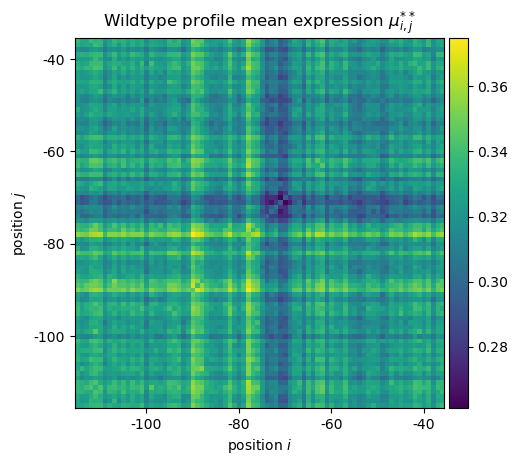

In [6]:
ax = plot_data_2d(mu[0,0], nan_color='k', norm=None, cmap='viridis')

ax.set_title("Wildtype profile mean expression $\\mu_{i,j}^{**}$");

We can then compute the expression shift $\xi$, which we define as the difference between the mean expression of sequences with mutation profiles $b$, $b'$ at positions $i$, $j$, respectively, and the mean wildtype expression.
Below, we compute and plot the expression shift when the first segment is not mutated and a single mutation is made at (i) the first base pair or (ii) the second base pair of the second segment.


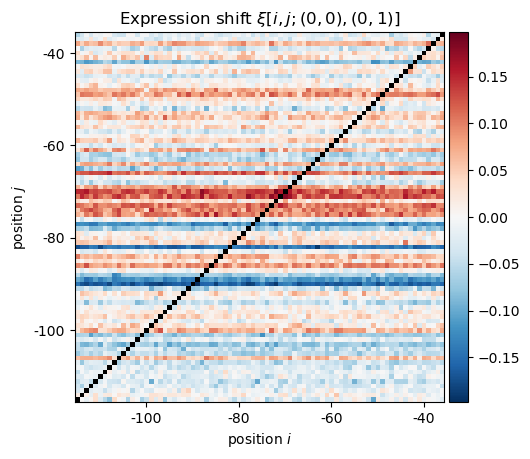

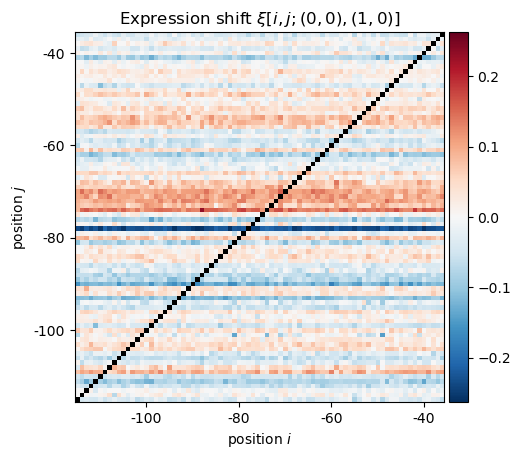

In [7]:
mutation_profiles = [
    [(0,0),(0,1)],
    [(0,0),(1,0)],
]

for b1, b2 in mutation_profiles:
    idx1 = binary_arr_to_int(np.array(b1))
    idx2 = binary_arr_to_int(np.array(b2))
    xi = mu[idx1, idx2] - mu[0, 0]
    ax = plot_data_2d(xi)
    ax.set_title(f"Expression shift $\\xi[i,j;{b1},{b2}]$")
    

The same computation can be found using the function `compute_expression_shift_by_mutation`.

Paired mutation profile: ([0 0], [0 1])
Paired mutation profile: ([0 0], [1 0])


/Users/addisonhowe/Documents/Projects/promoter-dissection/promdis/core.py:478: RuntimeWarning: invalid value encountered in divide
  mean_expression = total_expression / counts


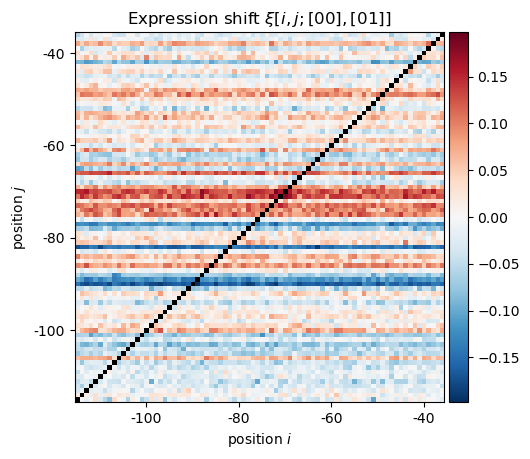

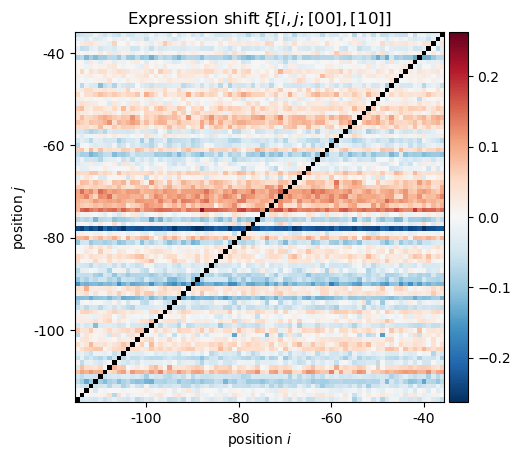

In [8]:
mutation_profiles = [
    [((0,0),(0,1))],
    [((0,0),(1,0))],
]

xis, profile_groups = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq, 
    segment_size=2,
    profile_groups=mutation_profiles
)

for xi, profiles in zip(xis, profile_groups):
    b1, b2  = profiles[0]
    print(f"Paired mutation profile: ({b1}, {b2})")
    ax = plot_data_2d(xi)
    ax.set_title(f"Expression shift $\\xi[i,j;{b1},{b2}]$")
    

Rather than calculate the mean expression of the profiles $(b_1, b_1')=((0,0), (0,1))$ and $(b_2,b_2')=((0,0),(1,0))$ separately, we may instead want to consider the mean expression when a single mutation is made to the second segment.
The same function lets us achieve this.
We specify the mutation profiles as follows:

/Users/addisonhowe/Documents/Projects/promoter-dissection/promdis/core.py:478: RuntimeWarning: invalid value encountered in divide
  mean_expression = total_expression / counts


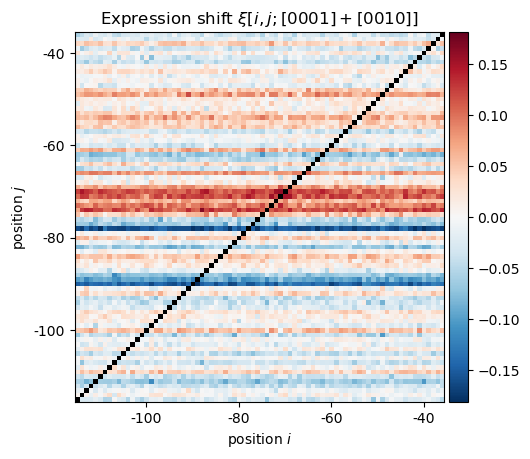

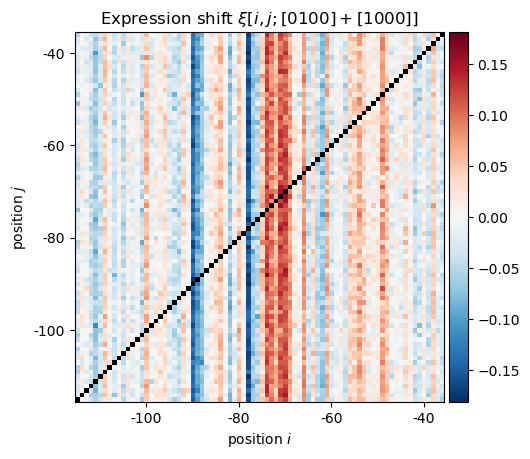

In [9]:
mutation_profiles = [
    [((0,0),(0,1)), ((0,0),(1,0))],
    [((0,1),(0,0)), ((1,0),(0,0))],
]

xis, profile_groups = compute_expression_shift_by_pairwise_mutation(
    seqs, expression, wt_seq, 
    segment_size=2,
    profile_groups=mutation_profiles
)

for xi, profile_group in zip(xis, profile_groups):
    ax = plot_data_2d(xi)
    s = "+".join([str(x) for x in profile_group.reshape([-1,4])])
    ax.set_title(f"Expression shift $\\xi[i,j;{s}]$");